# Concrete Compressive Strength Regression

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [15]:
df_train = pd.read_csv('concrete_training.csv')
df_test = pd.read_csv('concrete_test.csv')

## EDA

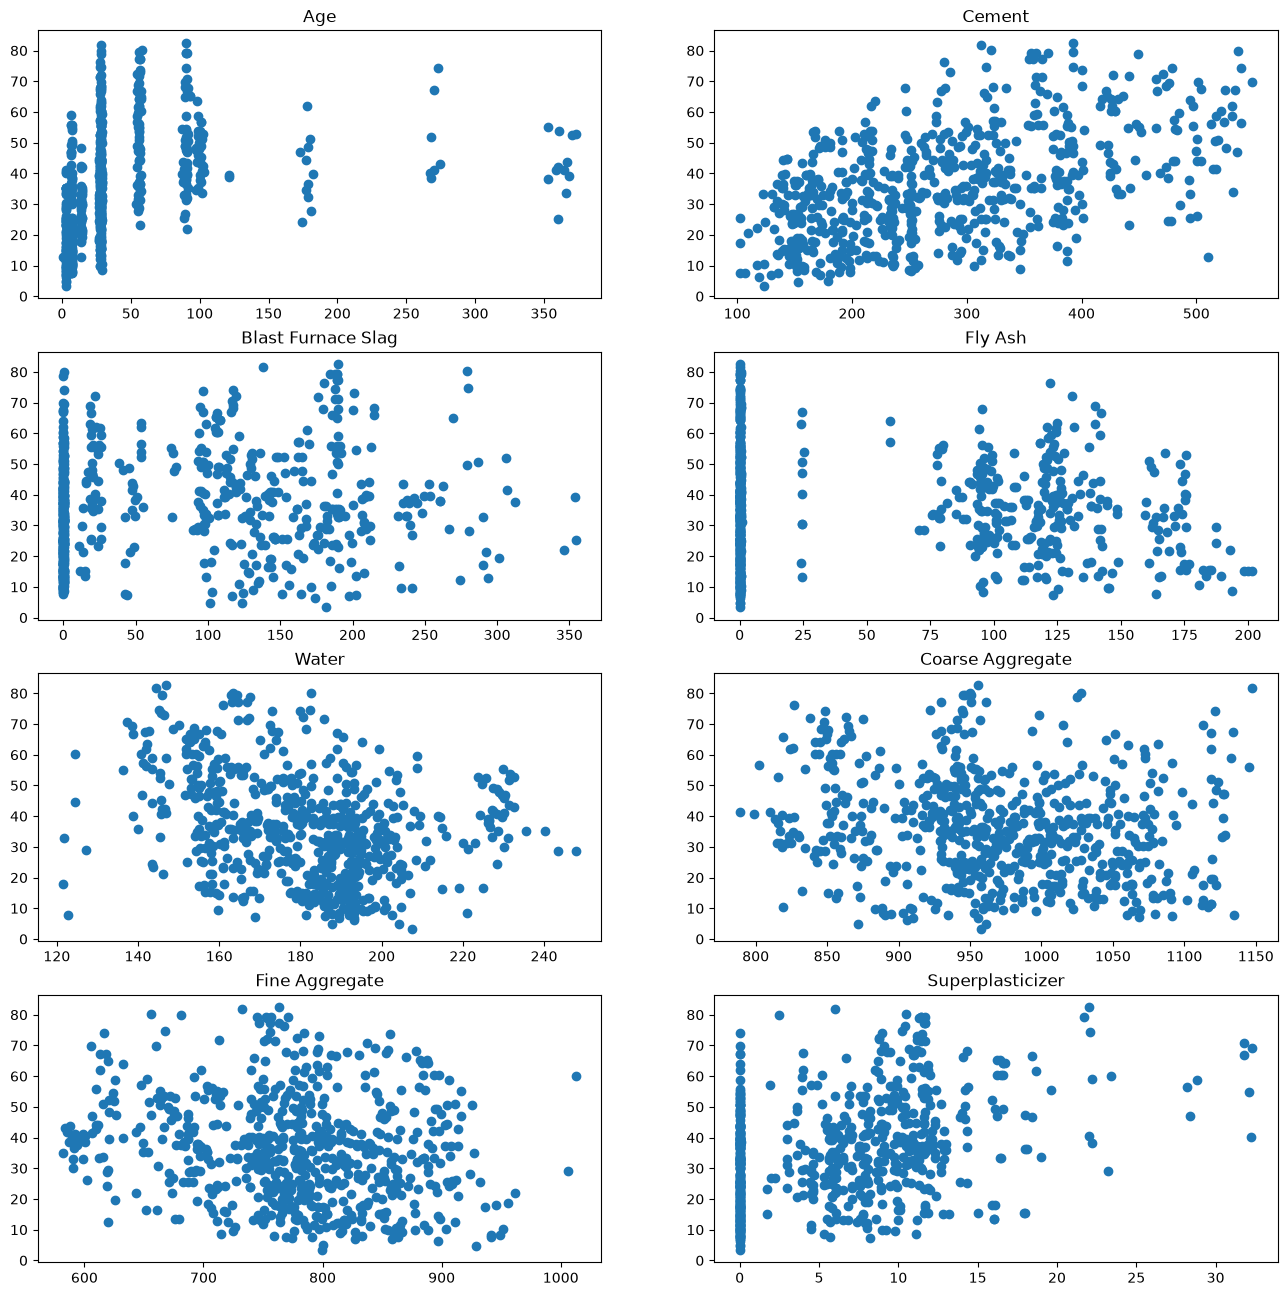

In [16]:
#EDA 
fig = plt.figure(figsize=(16, 16))

age = fig.add_subplot(4,2, 1)
plt.scatter(df_train.Age, df_train.Strength)
age.set_title("Age")

cem = fig.add_subplot(4,2, 2)
plt.scatter(df_train.Cement, df_train.Strength)
cem.set_title("Cement")

slag = fig.add_subplot(4,2, 3)
plt.scatter(df_train.BlastFurnaceSlag, df_train.Strength)
slag.set_title("Blast Furnace Slag")

fly = fig.add_subplot(4,2, 4)
plt.scatter(df_train.FlyAsh, df_train.Strength)
fly.set_title("Fly Ash")

water = fig.add_subplot(4,2, 5)
plt.scatter(df_train.Water, df_train.Strength)
water.set_title("Water")

ca = fig.add_subplot(4,2, 6)
plt.scatter(df_train.CoarseAggregate, df_train.Strength)
ca.set_title("Coarse Aggregate")

fa = fig.add_subplot(4,2, 7)
plt.scatter(df_train.FineAggregate, df_train.Strength)
fa.set_title("Fine Aggregate")

sup = fig.add_subplot(4,2, 8)
plt.scatter(df_train.Superplasticizer, df_train.Strength)
sup.set_title("Superplasticizer")

plt.show()

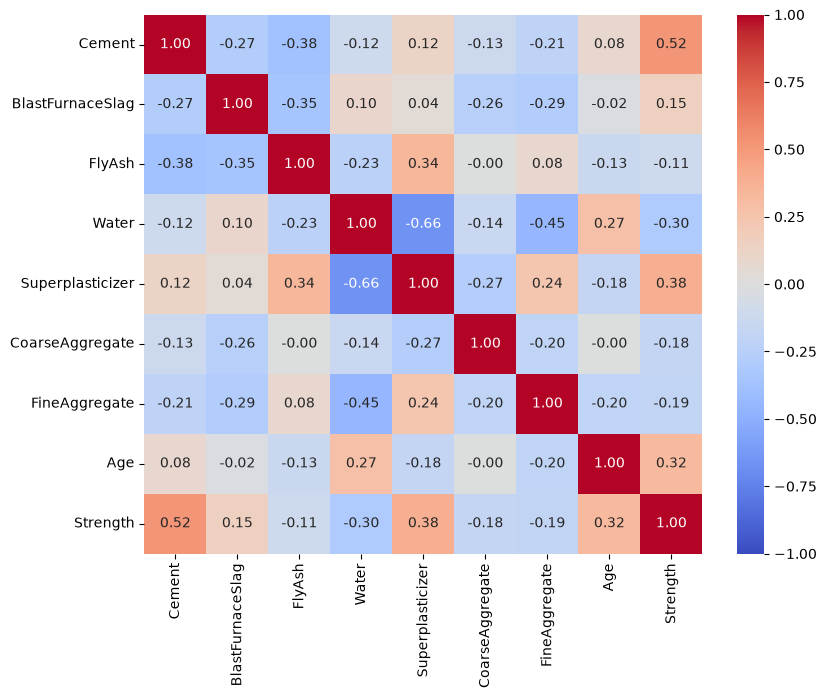

In [17]:
# Correlations between all variables
plt.figure(figsize=(9, 7))
sns.heatmap(df_train.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

## Model selection

In [18]:
# All eight predictors
model = smf.ols('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + Superplasticizer'
                ' + CoarseAggregate + FineAggregate + Age', data=df_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     139.5
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          1.66e-136
Time:                        20:29:29   Log-Likelihood:                -2517.0
No. Observations:                 670   AIC:                             5052.
Df Residuals:                     661   BIC:                             5092.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -7.3851     29.794  

In [19]:
# Drop Coarse and Fine Aggregate (not significant)
model = smf.ols('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + Superplasticizer + Age',
                data=df_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     185.9
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          1.90e-138
Time:                        20:29:29   Log-Likelihood:                -2517.7
No. Observations:                 670   AIC:                             5049.
Df Residuals:                     663   BIC:                             5081.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           26.3594      5.257  

## Checking assumptions

In [20]:
# Multicollinearity
X = model.model.exog
vif = pd.DataFrame({'variable': model.model.exog_names,
                    'VIF': [variance_inflation_factor(X, j) for j in range(X.shape[1])]})
print(vif.round(2))

           variable   VIF
0         Intercept  1.00
1            Cement  1.87
2  BlastFurnaceSlag  1.79
3            FlyAsh  2.28
4             Water  1.94
5  Superplasticizer  2.39
6               Age  1.10


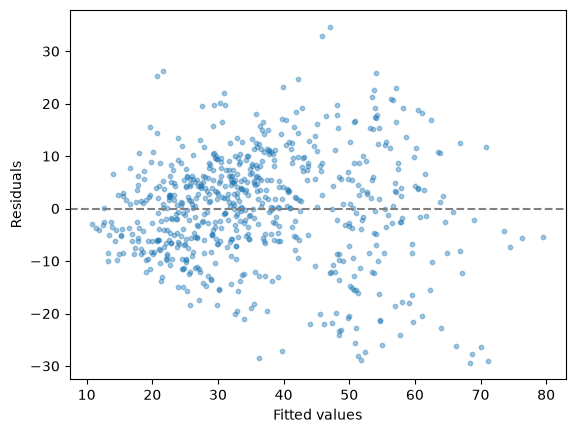

Breusch-Pagan p-value: 1.073778060943166e-16


In [21]:
# Heteroscedasticity: residual spread should be even across fitted values
plt.scatter(model.fittedvalues, model.resid, s=10, alpha=0.4)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

print('Breusch-Pagan p-value:', sms.het_breuschpagan(model.resid, model.model.exog)[1])

## Log transform and final model

In [22]:
# Replace Age with log(Age): strength rises quickly early on, then levels off
model = smf.ols('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + Superplasticizer + np.log(Age)',
                data=df_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     487.8
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          2.53e-239
Time:                        20:29:29   Log-Likelihood:                -2282.5
No. Observations:                 670   AIC:                             4579.
Df Residuals:                     663   BIC:                             4610.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            9.8999      3.659  

In [23]:
# Final model: drop Superplasticizer (not significant after the log transform)
# HC3 robust standard errors because the residuals are heteroscedastic 
final_model = smf.ols('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + np.log(Age)',
                      data=df_train).fit(cov_type='HC3')
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     588.8
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          3.01e-241
Time:                        20:29:29   Log-Likelihood:                -2282.8
No. Observations:                 670   AIC:                             4578.
Df Residuals:                     664   BIC:                             4605.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           11.2694      3.920  

## Final model

```
Strength = 11.2694 + 0.1118*Cement + 0.0895*BlastFurnaceSlag + 0.0636*FlyAsh - 0.2451*Water + 8.7184*ln(Age)
```

We selected this model using the backwards selection approach, as there are relatively few predictors and it lets us select what is necessary in a simple method. We dropped the coarse and fine aggregate due to having insignificant p-values. We then checked the necessary assumptions of a regression for any violations we may need to worry about with a residual plot which clarified a necessary concern about the heteroscedacity of the model.
We considered using weighted least squares, but instead elected to use a logarithmic transformation of age, as concrete's strength does not change much after it has fully hardened and the graphed data seems to support that. This also, along with  heteroscadacity-consistent standard errors adjustment helped correct the issue with a robust model.

## Test predictions

In [ ]:
predictions = pd.DataFrame({'ID': df_test['ID'], 'PredictedStrength': final_model.predict(df_test)})
predictions.to_csv('concrete_predictions.csv', index=False)
print(predictions.to_string(index=False))

 ID  PredictedStrength
  1          33.219217
  2          48.169531
  3          36.909539
  4          44.206228
  5          42.413048
  6          10.938503
  7          14.542841
  8          43.970899
  9          41.600806
 10          34.361827
 11           9.375785
 12          28.309785
 13          67.362946
 14          39.434283
 15          37.953675
 16          34.053252
 17          61.309096
 18          26.684010
 19          18.129500
 20          57.771103
 21          34.284300
 22          23.019403
 23          24.906064
 24          26.045023
 25          42.724690
 26          -1.843717
 27          45.801323
 28          53.904096
 29          32.323374
 30          65.511484
